In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import time

In [2]:
def monte_carlo_pi(num_points):
    # Menghitung titik random dalam kotak berukuran 1x1
    x = np.random.random(num_points)
    y = np.random.random(num_points)
    
    # Menghitung jarak dari pusat lingkaran (0.5, 0.5) dengan radius 0.5
    distances = np.sqrt((x - 0.5)**2 + (y - 0.5)**2)
    
    # Menghitung jumlah titik yang ada di dalam lingkaran (jarak <= 0.5)
    points_inside_circle = np.sum(distances <= 0.5)
    
    # Menghitung pi berdasarkan perbandingan luas lingkaran dan kotak
    pi_estimate = 4 * points_inside_circle / num_points
    
    return pi_estimate, x, y, distances

In [3]:
def visualize_simulation(x, y, distances, num_points):
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Membuat kotak
    rect = Rectangle((0, 0), 1, 1, fill=False, edgecolor='blue', linewidth=2)
    ax.add_patch(rect)
    
    # Membuat lingkaran
    circle = Circle((0.5, 0.5), 0.5, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(circle)
    
    # Plot titik-titik
    inside_circle = distances <= 0.5
    ax.scatter(x[inside_circle], y[inside_circle], color='red', s=1, alpha=0.5, label='Dalam lingkaran')
    ax.scatter(x[~inside_circle], y[~inside_circle], color='blue', s=1, alpha=0.5, label='Luar lingkaran')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'Simulasi Monte Carlo untuk π dengan {num_points} titik')
    ax.legend()
    plt.tight_layout()
    
    return fig

In [4]:
def run_pi_experiment(max_points=1000000, num_steps=20):
    points_list = np.logspace(2, np.log10(max_points), num_steps, dtype=int)
    pi_estimates = []
    errors = []
    execution_times = []
    
    for n in points_list:
        start_time = time.time()
        pi_estimate, _, _, _ = monte_carlo_pi(n)
        end_time = time.time()
        
        execution_time = end_time - start_time
        error = abs(pi_estimate - np.pi)
        
        pi_estimates.append(pi_estimate)
        errors.append(error)
        execution_times.append(execution_time)
        
        print(f"Jumlah titik: {n}, Estimasi π: {pi_estimate:.6f}, Error: {error:.6f}, Waktu: {execution_time:.4f} detik")
    
    return points_list, pi_estimates, errors, execution_times

Estimasi nilai π dengan 100000 titik: 3.13512
Nilai π sebenarnya: 3.141592653589793
Error: 0.006472653589792987


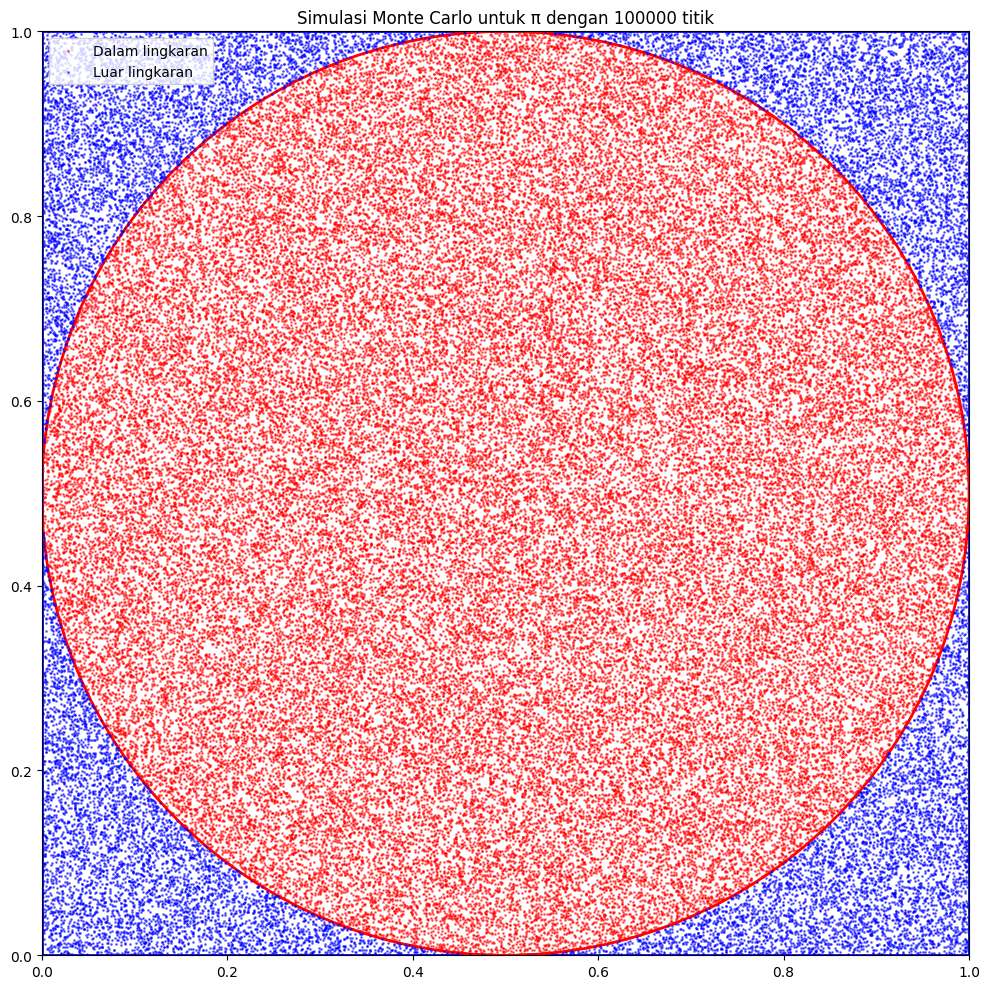


Menjalankan eksperimen dengan berbagai jumlah titik...
Jumlah titik: 100, Estimasi π: 3.200000, Error: 0.058407, Waktu: 0.0002 detik
Jumlah titik: 278, Estimasi π: 3.194245, Error: 0.052652, Waktu: 0.0003 detik
Jumlah titik: 774, Estimasi π: 3.152455, Error: 0.010862, Waktu: 0.0002 detik
Jumlah titik: 2154, Estimasi π: 3.097493, Error: 0.044100, Waktu: 0.0001 detik
Jumlah titik: 5994, Estimasi π: 3.160494, Error: 0.018901, Waktu: 0.0002 detik
Jumlah titik: 16681, Estimasi π: 3.160722, Error: 0.019129, Waktu: 0.0003 detik
Jumlah titik: 46415, Estimasi π: 3.135538, Error: 0.006055, Waktu: 0.0372 detik
Jumlah titik: 129154, Estimasi π: 3.145021, Error: 0.003428, Waktu: 0.0080 detik
Jumlah titik: 359381, Estimasi π: 3.145943, Error: 0.004350, Waktu: 0.0177 detik
Jumlah titik: 1000000, Estimasi π: 3.139220, Error: 0.002373, Waktu: 0.0566 detik


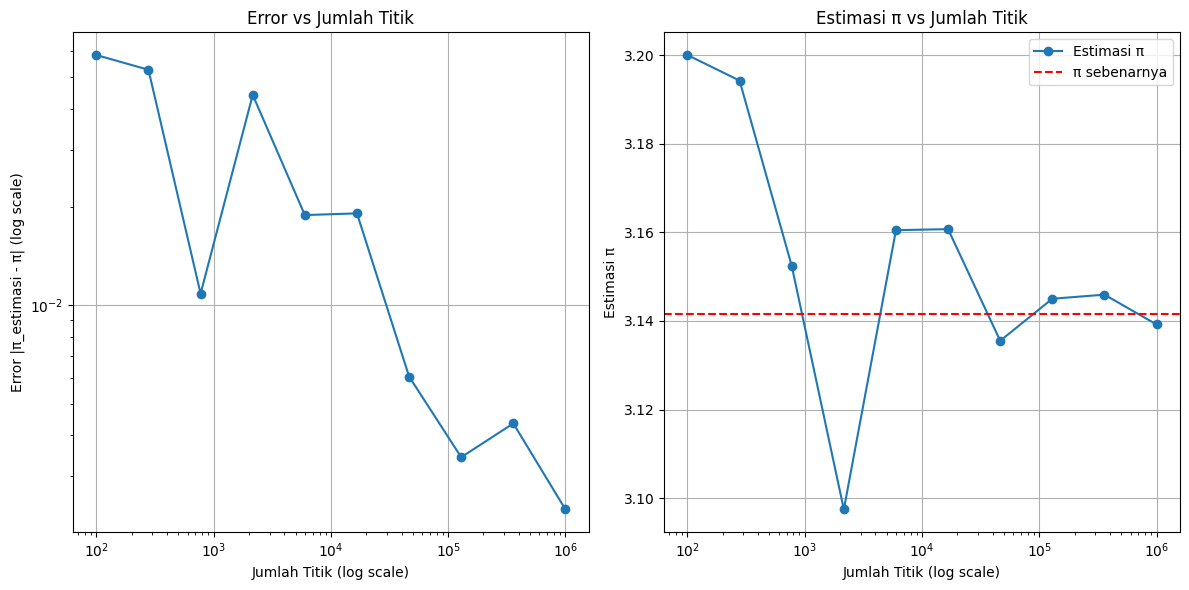

In [5]:
if __name__ == "__main__":
    # Menjalankan simulasi dengan jumlah titik tertentu
    num_points = 100000
    pi_estimate, x, y, distances = monte_carlo_pi(num_points)
    
    print(f"Estimasi nilai π dengan {num_points} titik: {pi_estimate}")
    print(f"Nilai π sebenarnya: {np.pi}")
    print(f"Error: {abs(pi_estimate - np.pi)}")
    
    # Visualisasi simulasi
    fig = visualize_simulation(x, y, distances, num_points)
    plt.savefig('monte_carlo_pi_visualization.png')
    plt.show()
    
    # Menjalankan eksperimen dengan berbagai jumlah titik
    print("\nMenjalankan eksperimen dengan berbagai jumlah titik...")
    points_list, pi_estimates, errors, execution_times = run_pi_experiment(max_points=1000000, num_steps=10)
    
    # Membuat grafik error berdasarkan jumlah titik
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.loglog(points_list, errors, 'o-')
    plt.xlabel('Jumlah Titik (log scale)')
    plt.ylabel('Error |π_estimasi - π| (log scale)')
    plt.title('Error vs Jumlah Titik')
    plt.grid(True)
    
    # Membuat grafik estimasi π berdasarkan jumlah titik
    plt.subplot(1, 2, 2)
    plt.semilogx(points_list, pi_estimates, 'o-', label='Estimasi π')
    plt.axhline(y=np.pi, color='r', linestyle='--', label='π sebenarnya')
    plt.xlabel('Jumlah Titik (log scale)')
    plt.ylabel('Estimasi π')
    plt.title('Estimasi π vs Jumlah Titik')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('monte_carlo_pi_results.png')
    plt.show()